<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/TrabalhoFinal/TrabalhoFinalComputerVisionV6_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=1F3A5F>**Trabalho Final — Computer Vision: Sistema de Autenticação Facial Bancária**</font>
361721 João Vitor Azevedo Jacundá Santos<br>360815 Mariana Nagoshi Yashima<br>



###**Contexto**

O setor de fraudes identificou clientes que alegam não ter contratado serviços específicos (ex.: crédito pessoal), mesmo com autenticação por senha confirmada. Para mitigar esse risco, o banco implementará uma **autenticação biométrica facial complementar**, aplicada em serviços de maior risco.

###**Objetivos**
1. **Detecção de faces** — localizar e recortar rostos na imagem.
2. **Identificação facial** — confirmar a identidade do cliente via comparação de embeddings.
3. **Detecção de vivacidade (liveness)** — rejeitar tentativas de fraude com foto estática.

###**Arquitetura escolhida**
| Componente | Modelo | Justificativa |
|---|---|---|
| Detecção | YuNet (OpenCV Zoo) | Rápido e preciso em CPU; roda bem no Colab |
| Identificação | SFace (OpenCV Zoo) | Embeddings de 128 dims, comparação por cosseno |
| Liveness | FaceLandmarker (MediaPipe Tasks API) | 478 landmarks; ideal para cálculo de EAR |

###**Fluxo de autenticação**
```
Cadastro (Enrollment)             Autenticação em tempo real
─────────────────────             ──────────────────────────────────────────────
N fotos do cliente → galeria  →   comparação SFace (cosseno) ┐
                                                              ├─→ APROVADO  → acesso liberado
vídeo/webcam → EAR → piscada  →   liveness detectado ────────┘
                                                              ↓
                                                         EM_REVISAO
                                                              ↓
                         ┌──────────────────────────────────────────────────┐
                         │  ESTEIRA DEDICADA DE FRAUDES                     │
                         │  • Cliente atendido por canal alternativo         │
                         │  • Evidências (imagem + JSON) salvas em disco     │
                         │  • Encaminhadas à área de IA para retreino        │
                         └──────────────────────────────────────────────────┘
```

---

## 📋 Checklist de execução

| # | Seção | O que fazer |
|---|---|---|
| 1 | Configuração do Ambiente | Executar **uma vez** por sessão |
| 2 | Imports e Paths | Executar sempre após reiniciar kernel |
| 3 | Download dos Modelos | Executar uma vez (usa cache automático) |
| 4 | YuNet — Detecção | Inicializar modelos e testar com imagem de exemplo |
| 5 | SFace — Identificação | Carregar funções, depois cadastrar clientes |
| 5.1 ⚠️ | Opção A **ou** B | Executar **apenas uma** das células de captura |
| 6 | Liveness (EAR) | Instalar MediaPipe e carregar funções |
| 7 | Pipeline completo | Executar autenticação fim a fim |
| 8 | Esteira de Fraudes | Referência de negócio — sem execução necessária |
| 9 | Limiares e Governança | Calibrar thresholds com dados reais |


## <font color=#355C7D>**1. Configuração do Ambiente**</font>
> Execute esta seção **uma única vez** ao iniciar o Colab. Ela clona o repositório, instala dependências e baixa os modelos.


In [ ]:
# Clonar repositório e instalar OpenCV com contrib (necessário para YuNet/SFace)
!git clone https://github.com/jacunda/POS-DATASCIENCE-IA.git
%cd /content/POS-DATASCIENCE-IA/TrabalhoFinal
!apt-get install -y libopencv-dev -q


Cloning into 'POS-DATASCIENCE-IA'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 88 (delta 13), reused 19 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 26.09 MiB | 9.65 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/POS-DATASCIENCE-IA/TrabalhoFinal
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libi

## <font color=#355C7D>**2. Imports de bibliotecas e Configuração de Path**</font>
---




In [ ]:
import os, ssl, json, math, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy.spatial import distance as dist
from tqdm import tqdm
import urllib.request
import IPython.display as ipydisplay
from IPython.display import display, Javascript, HTML, Image as IPyImage
from base64 import b64decode, b64encode
%matplotlib inline

# ── Caminhos base ────────────────────────────────────────
BASE_DIR      = Path.cwd()
MODEL_DIR     = BASE_DIR / 'models'
DATA_DIR      = BASE_DIR / 'data'
ENROLL_DIR    = DATA_DIR / 'enroll'
TEST_DIR      = DATA_DIR / 'test'
EVIDENCE_DIR  = BASE_DIR / 'evidencias'
LANDMARKER_PATH = MODEL_DIR / 'face_landmarker.task'

for d in [MODEL_DIR, EVIDENCE_DIR, ENROLL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Diretório base: {BASE_DIR}')
print(f'numpy={np.__version__}  cv2={cv2.__version__}')


Diretório base: /content/POS-DATASCIENCE-IA/TrabalhoFinal
numpy=2.0.2  cv2=4.13.0


## <font color=#355C7D>**3. Download dos Modelos**</font>



In [ ]:
# ============================================================
# PASSO 2 — Download dos modelos
# Execute após reiniciar o kernel (após o PASSO 1).
# ============================================================
import os
import ssl
import urllib.request
from pathlib import Path

# Cria os diretórios necessários para armazenar os modelos e dados
os.makedirs("models", exist_ok=True)
os.makedirs("data/enroll", exist_ok=True)
os.makedirs("data/test", exist_ok=True)
os.makedirs("evidencias", exist_ok=True)

# Define os URLs para download dos modelos YuNet, SFace e FaceLandmarker
MODEL_URLS = {
    "face_landmarker.task": (
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/face_landmarker.task"
    ),
    "face_detection_yunet_2023mar.onnx": (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_detection_yunet/face_detection_yunet_2023mar.onnx"
    ),
    "face_recognition_sface_2021dec.onnx": (
        "https://github.com/opencv/opencv_zoo/raw/main/models/"
        "face_recognition_sface/face_recognition_sface_2021dec.onnx"
    ),
}

def _download_with_urllib(url: str, dst_path: Path):

    try:
        urllib.request.urlretrieve(url, str(dst_path))
    except Exception:
        ctx = ssl._create_unverified_context()
        with urllib.request.urlopen(url, context=ctx, timeout=60) as response, open(dst_path, "wb") as out:
            out.write(response.read())

def _download_with_requests(url: str, dst_path: Path):
    import requests
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dst_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

def download_file(url: str, dst_path: Path):
    # Verifica se o arquivo já existe e não está vazio para evitar downloads repetidos
    if dst_path.exists() and dst_path.stat().st_size > 0:
        return "cached"

    # Tenta baixar o arquivo usando urllib ou requests
    try:
        _download_with_urllib(url, dst_path)
    except Exception as err_urllib:
        try:
            _download_with_requests(url, dst_path)
        except Exception as err_requests:
            raise RuntimeError(
                f"Falha ao baixar {dst_path.name}\n"
                f"urllib: {err_urllib}\n"
                f"requests: {err_requests}"
            )

    # Verifica se o download foi bem-sucedido
    if not dst_path.exists() or dst_path.stat().st_size == 0:
        raise RuntimeError(f"Download inválido: {dst_path.name} ficou vazio.")

    return "downloaded"


print("Iniciando download dos modelos...\n")
# Itera sobre os modelos definidos e os baixa
for model_name, url in MODEL_URLS.items():
    dst = Path("models") / model_name
    status = download_file(url, dst)
    size_kb = dst.stat().st_size // 1024
    flag = "✅" if status in {"cached", "downloaded"} else "⚠️"
    print(f"{flag} {model_name} ({size_kb} KB) - {status}")

print("\nModelos disponíveis em ./models:")
# Lista os modelos baixados na pasta 'models'
for f in sorted(os.listdir("models")):
    size_kb = os.path.getsize(f"models/{f}") // 1024
    print(f"   - {f} ({size_kb} KB)")

Iniciando download dos modelos...

✅ face_landmarker.task (3670 KB) - cached
✅ face_detection_yunet_2023mar.onnx (227 KB) - cached
✅ face_recognition_sface_2021dec.onnx (37789 KB) - downloaded

Modelos disponíveis em ./models:
   - face_detection_yunet_2023mar.onnx (227 KB)
   - face_landmarker.task (3670 KB)
   - face_recognition_sface_2021dec.onnx (37789 KB)


## <font color=#355C7D>**4. Detecção de Faces — YuNet**</font>

O **YuNet** é um detector leve baseado em rede neural convolucional, disponível no OpenCV Zoo. Ele retorna bounding boxes e landmarks dos 5 pontos-chave do rosto (olhos, nariz, cantos da boca).

> **Para testar:** coloque uma imagem em `data/test/exemplo.jpg` ou ajuste a variável `test_img_path` abaixo.


In [ ]:
# Inicialização dos modelos e funções utilitárias
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define os caminhos para os modelos YuNet (detecção) e SFace (reconhecimento)
yunet_path = MODEL_DIR / "face_detection_yunet_2023mar.onnx"
sface_path = MODEL_DIR / "face_recognition_sface_2021dec.onnx"

# Se esta célula falhar: Ambiente de Execução → Reiniciar sessão.
try:
    # Inicializa o detector de faces YuNet
    detector = cv2.FaceDetectorYN.create(
        model=str(yunet_path),
        config="",
        input_size=(320, 320),
        score_threshold=0.85,  # confiança mínima para aceitar uma detecção (0.0 a 1.0)
        nms_threshold=0.3,     # NMS (Non-Maximum Suppression) para remover bounding boxes sobrepostas
        top_k=5000,            # número máximo de detecções de faces a serem consideradas
    )
    # Inicializa o reconhecedor facial SFace
    recognizer = cv2.FaceRecognizerSF.create(model=str(sface_path), config="")
    print("✅ Modelos YuNet e SFace inicializados com sucesso!")
except AttributeError as e:
    print(f"❌ Erro: {e}")
    print("   DICA: Reinicie a sessão do Colab e execute novamente.")


def read_image(path: str) -> np.ndarray:
    """
    Lê uma imagem do caminho especificado usando OpenCV.
    Levanta FileNotFoundError se a imagem não for encontrada.
    """
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    return img


def detect_faces(img_bgr: np.ndarray) -> list:
    """
    Detecta faces na imagem BGR usando o modelo YuNet.
    Ajusta o tamanho de entrada do detector para corresponder ao da imagem.
    Retorna uma lista de faces detectadas, ordenadas pela confiança (score).
    Cada face é um vetor de 15 valores (bounding box, landmarks e score (score=14 por ser o 15º valor do vetor)).
    """
    h, w = img_bgr.shape[:2]
    detector.setInputSize((w, h))
    _, faces = detector.detect(img_bgr)
    if faces is None:
        return []
    # Ordena as faces pela confiança (score) em ordem decrescente (f[14] é o score)
    return sorted(faces, key=lambda f: float(f[14]), reverse=True)


def draw_faces(img_bgr: np.ndarray, faces: list, title: str = "Detecção") -> None:
    """
    Exibe a imagem com as bounding boxes e os scores de confiança das faces detectadas.
    Desenha um retângulo verde ao redor de cada face e exibe o score.
    """
    vis = img_bgr.copy()
    for face in faces:
        # Extrai coordenadas da bounding box
        x, y, w, h = map(int, face[:4])
        score = float(face[14]) # Score de confiança
        # Desenha o retângulo
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # Adiciona o texto com o score de confiança
        cv2.putText(
            vis, f"conf={score:.3f}",
            (x, max(y - 8, 20)), # Posição do texto acima da bounding box
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2,
        )
    # Exibe a imagem usando matplotlib
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)) # Converte BGR para RGB para exibição correta
    plt.axis("off") # Remove os eixos
    plt.show()


✅ Modelos YuNet e SFace inicializados com sucesso!


Faces detectadas: 1


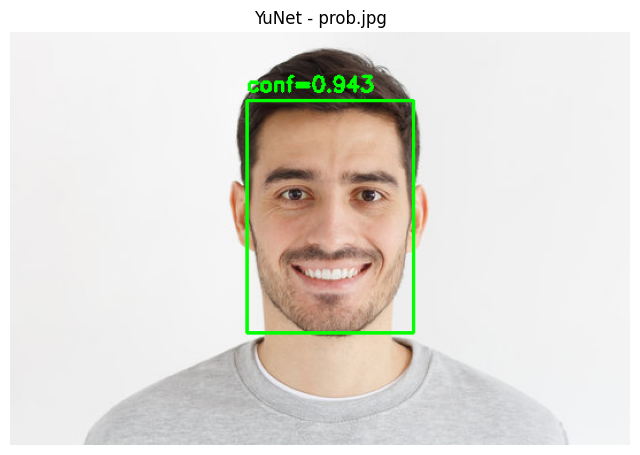

In [ ]:
# Exemplo de uso do detector
test_img_path = TEST_DIR / "prob.jpg"

if test_img_path.exists():
    img = read_image(str(test_img_path))
    faces = detect_faces(img)
    print(f"Faces detectadas: {len(faces)}")
    draw_faces(img, faces, title=f"YuNet - {test_img_path.name}")
else:
    print(f"Coloque uma imagem em: {test_img_path}")

### O que o YuNet retorna?

Cada face detectada é um vetor de **15 valores**:

| Índices | Conteúdo |
|---|---|
| `[0:4]` | Bounding box: `x, y, largura, altura` (em pixels) |
| `[4:14]` | Landmarks de 5 pontos-chave: olho esq, olho dir, nariz, canto esq da boca, canto dir da boca (x,y de cada) |
| `[14]` | **Score de confiança** — valor entre 0.0 e 1.0 |




## <font color=#355C7D>**5. Identificação Facial — SFace**</font>

O **SFace** extrai um vetor de características (embedding) de 128 dimensões para cada face. A comparação entre dois embeddings é feita via **similaridade de cosseno**: quanto mais próximo de 1.0, mais parecidas as faces.

O threshold padrão é `0.363` (L2) ou `0.593` (cosseno) — valores recomendados pelo OpenCV Zoo para este modelo.


In [ ]:
def get_face_embedding(img_bgr: np.ndarray):
    """
    Detecta a primeira face em uma imagem e extrai seu embedding (vetor de características)
    usando o modelo SFace.

    Parâmetros
    ----------
    img_bgr : Imagem no formato BGR (OpenCV).

    Retorna
    -------
    tuple: (feat, face) onde feat é o embedding da face e face é a bounding box com landmarks.
           Retorna (None, None) se nenhuma face for detectada.
    """
    # Detecta as faces na imagem usando o YuNet
    faces = detect_faces(img_bgr)
    if len(faces) == 0:
        return None, None
    # Pega a primeira face detectada (a de maior confiança)
    face = faces[0].astype(np.float32)
    # Alinha e recorta a face para alimentar o modelo SFace
    aligned = recognizer.alignCrop(img_bgr, face)
    # Extrai o vetor de características (embedding) da face alinhada
    feat = recognizer.feature(aligned)
    return feat, face

def cosine_similarity(f1, f2):
    """
    Calcula a similaridade de cosseno entre dois embeddings faciais.
    Quanto mais próximo de 1.0, mais similares são as faces.

    Parâmetros
    ----------
    f1 : Primeiro embedding facial.
    f2 : Segundo embedding facial.

    Retorna
    -------
    float : Valor da similaridade de cosseno.
    """
    # O método 'match' do FaceRecognizerSF calcula a similaridade de cosseno
    return float(recognizer.match(f1, f2, cv2.FaceRecognizerSF_FR_COSINE))

def build_gallery(enroll_root: Path):
    """
    Constrói uma galeria de embeddings faciais a partir de imagens de cadastro.
    Cada pessoa (subdiretório em enroll_root) pode ter múltiplos embeddings.

    Parâmetros
    ----------
    enroll_root : Caminho para o diretório raiz de cadastro (ex: data/enroll).

    Retorna
    -------
    dict : Dicionário onde a chave é o ID do cliente e o valor é uma lista de seus embeddings.
    """
    gallery = {}
    if not enroll_root.exists():
        return gallery

    # Itera sobre cada subdiretório (representando um cliente)
    for person_dir in sorted([p for p in enroll_root.iterdir() if p.is_dir()]):
        person_id = person_dir.name
        feats = []
        # Itera sobre as imagens JPG de cada cliente
        for img_path in person_dir.glob("*.jpg"):
            img = read_image(str(img_path))
            # Extrai o embedding de cada face na imagem
            feat, face = get_face_embedding(img)
            if feat is not None:
                feats.append(feat)
        if feats:
            gallery[person_id] = feats
    return gallery

def identify_person(probe_img_bgr: np.ndarray, gallery: dict, threshold: float = 0.35):
    """
    Identifica uma pessoa em uma imagem de "sonda" (probe) comparando seu embedding
    com os embeddings na galeria.

    Parâmetros
    ----------
    probe_img_bgr : Imagem de sonda no formato BGR (OpenCV).
    gallery       : Galeria de embeddings faciais (resultado de build_gallery).
    threshold     : Limiar de similaridade de cosseno para considerar um "MATCH".

    Retorna
    -------
    dict : Dicionário com o status da identificação (MATCH, NO_MATCH, NO_FACE),
           o ID da melhor correspondência, o score e a bounding box da face detectada.
    """
    # Extrai o embedding da face na imagem de sonda
    probe_feat, probe_face = get_face_embedding(probe_img_bgr)
    if probe_feat is None:
        return {"status": "NO_FACE", "best_id": None, "score": 0.0, "face": None}

    best_id = None
    best_score = -1.0

    # Compara o embedding da sonda com todos os embeddings na galeria
    for person_id, feat_list in gallery.items():
        # Calcula o score de similaridade com cada embedding do cliente
        scores = [cosine_similarity(probe_feat, f) for f in feat_list]
        # Pega o score máximo para o cliente (melhor correspondência)
        person_score = max(scores) if scores else -1.0
        # Atualiza a melhor correspondência encontrada até agora
        if person_score > best_score:
            best_score = person_score
            best_id = person_id

    # Determina o status final com base no threshold
    status = "MATCH" if best_score >= threshold else "NO_MATCH"
    return {
        "status": status,
        "best_id": best_id,
        "score": float(best_score),
        "face": probe_face,
    }


###<font color=AFC1D9> **5.1 Cadastro de Cliente (Enrollment)**</font>
Ajuste as variáveis `CLIENTE_ID`, `N_FOTOS` e `MODO` antes de executar.
- `MODO = 'webcam'` → captura via câmera do navegador.
- `MODO = 'upload'` → envie fotos do seu dispositivo.

> **Boas práticas:** use 3 a 5 fotos com variações leves de ângulo e iluminação para um embedding mais robusto.


####<font color=D7C3F3> **5.1.1 Como funciona a captura**</font>


Para o cadastro e a autenticação, você pode usar **duas abordagens** de captura:

| | **Opção A — Webcam** | **Opção B — Upload** |
|---|---|---|
| **Quando usar** | Ambiente com câmera disponível (laptop/desktop) | Fotos/vídeos já gravados no dispositivo |
| **Vantagem** | Captura ao vivo, mais realista | Flexível, funciona sem câmera |
| **Para cadastro** | `take_photo()` | `upload_photo()` |
| **Para liveness** | `capture_frames()` — grava ~25 frames com contagem regressiva | `upload_video_and_extract_frames()` — extrai frames de um vídeo |

> **Dica:** execute **apenas a célula da opção que você vai usar**. Não é necessário executar as duas.


#### Opção A — Webcam (captura ao vivo)

Usa a câmera do navegador diretamente no Google Colab via JavaScript.

**Funções definidas nesta célula:**
- `take_photo(filename)` → abre a câmera, exibe o vídeo ao vivo e salva uma foto ao clicar no botão vermelho.
- `capture_frames(n_frames, interval_ms)` → exibe contagem regressiva, depois grava `n_frames` quadros em sequência (usado para detectar piscada no liveness).

**Pré-requisito:** estar rodando no Google Colab e permitir o acesso à câmera quando o navegador solicitar.


In [ ]:
import IPython.display as display
import base64

# Verifica se o código está sendo executado no ambiente Google Colab
try:
    from google.colab import output as colab_output
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    # Stubs (objetos simulados) para permitir que o código rode fora do Colab
    # sem erros de importação, levantando um erro se as funções do Colab forem chamadas.
    class _FallbackOutput:
        @staticmethod
        def eval_js(*args, **kwargs):
            raise EnvironmentError("google.colab não está disponível. Execute no Google Colab.")
    class _FallbackFiles:
        @staticmethod
        def upload():
            raise EnvironmentError("google.colab.files não está disponível. Execute no Google Colab.")
    colab_output = _FallbackOutput()
    colab_files  = _FallbackFiles()


# ── Opção A-1: Foto única via webcam (para cadastro e identificação) ──────────
def take_photo(filename: str, quality: float = 0.8) -> str:
    """
    Abre a câmera do navegador, exibe o vídeo ao vivo e captura
    uma foto ao clicar no botão vermelho. Salva o arquivo em `filename`.

    Parâmetros
    ----------
    filename : caminho onde a foto será salva (ex.: "data/enroll/cliente_001/img1.jpg")
    quality  : qualidade JPEG — 0.0 (menor) a 1.0 (maior). Padrão: 0.8

    Retorna
    -------
    str : caminho do arquivo salvo
    """
    # Código JavaScript injetado no navegador para controlar a câmera e capturar a foto.
    # Este JS é responsável por:
    # 1. Solicitar acesso à câmera do usuário.
    # 2. Exibir o feed de vídeo na página.
    # 3. Adicionar um botão de 'Capturar Foto'.
    # 4. Ao clicar, desenhar o frame atual do vídeo em um canvas e convertê-lo para Data URL.
    # 5. Parar o stream da câmera e remover os elementos da interface.
    # 6. Retornar a Data URL da imagem capturada para o Python.
    js = """
    async function capturePhoto(quality) {
        return new Promise((resolve, reject) => {
            const div = document.createElement('div');
            document.body.appendChild(div);
            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;height:auto;';
            div.appendChild(video);
            navigator.mediaDevices.getUserMedia({ video: true }).then(stream => {
                video.srcObject = stream;
                video.play();
                const button = document.createElement('button');
                button.innerText = '📷 Capturar Foto';
                button.style.cssText = 'display:block;margin-top:10px;padding:10px;font-size:16px;cursor:pointer;background:red;color:white;';
                div.appendChild(button);
                button.onclick = () => {
                    const canvas = document.createElement('canvas');
                    canvas.width = video.videoWidth;
                    canvas.height = video.videoHeight;
                    canvas.getContext('2d').drawImage(video, 0, 0);
                    stream.getTracks().forEach(t => t.stop());
                    div.remove();
                    resolve(canvas.toDataURL('image/jpeg', quality));
                };
            }).catch(err => { div.remove(); reject(err); });
        });
    }
    """
    # Cria os diretórios necessários para salvar a foto, se não existirem
    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)
    # Exibe o JavaScript no notebook, que executa no navegador
    display.display(display.Javascript(js))
    # Avalia a função JavaScript 'capturePhoto' e obtém a Data URL da imagem
    data_url = colab_output.eval_js(f'capturePhoto({quality})')
    # Verifica se a captura foi bem-sucedida e se a Data URL é válida
    if not data_url or ',' not in data_url:
        raise ValueError("Nenhuma imagem capturada. Tente novamente.")
    # Decodifica a string base64 da imagem e salva como arquivo JPG usando OpenCV
    encoded = data_url.split(',')[1]
    encoded += '=' * (-len(encoded) % 4) # Garante padding correto para base64
    image = cv2.imdecode(np.frombuffer(base64.b64decode(encoded), np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("OpenCV falhou ao decodificar a imagem capturada.")
    cv2.imwrite(filename, image)
    print(f"📷 Foto salva em: {filename}")
    return filename


# ── Opção A-2: Sequência de frames via webcam (para liveness) ────────────────
def capture_frames(n_frames: int = 25, interval_ms: int = 150, quality: float = 0.7) -> list:
    """
    Exibe contagem regressiva de 3 segundos e depois grava `n_frames` quadros
    com intervalo de `interval_ms` ms entre cada um. Durante a gravação,
    o usuário deve piscar os olhos — esses frames alimentam o algoritmo EAR.

    Parâmetros
    ----------
    n_frames    : número de frames a capturar (padrão: 25 ≈ ~3.75 s a 150 ms/frame)
    interval_ms : intervalo entre frames em milissegundos (padrão: 150 ms)
    quality     : qualidade JPEG (padrão: 0.7)

    Retorna
    -------
    list : lista de frames NumPy no formato BGR
    """
    # Código JavaScript para capturar uma sequência de frames, usado para detecção de liveness.
    # Este JS é responsável por:
    # 1. Exibir uma mensagem ao usuário para olhar para a câmera e piscar.
    # 2. Iniciar uma contagem regressiva de 3 segundos.
    # 3. Após a contagem, começar a capturar 'n_frames' com um 'interval_ms' entre eles.
    # 4. Durante a captura, atualizar o texto para indicar o progresso e instruir o usuário a piscar.
    # 5. Coletar os frames como Data URLs.
    # 6. Retornar a lista de Data URLs para o Python.
    js = f"""
    async function captureFrames(nFrames, intervalMs, quality) {{
        return new Promise((resolve, reject) => {{
            const div = document.createElement('div');
            document.body.appendChild(div);
            const label = document.createElement('p');
            label.style.cssText = 'font-size:18px;font-weight:bold;color:#333;';
            label.innerText = '👁 Olhe para a câmera e PISCE os olhos quando solicitado!';
            div.appendChild(label);
            const video = document.createElement('video');
            video.style.cssText = 'width:100%;max-width:640px;';
            div.appendChild(video);
            const countdown = document.createElement('p');
            countdown.style.cssText = 'font-size:24px;font-weight:bold;color:red;';
            div.appendChild(countdown);
            navigator.mediaDevices.getUserMedia({{ video: true }}).then(stream => {{
                video.srcObject = stream;
                video.play().then(() => {{
                    let count = 3;
                    countdown.innerText = 'Iniciando em: ' + count + 's';
                    const tick = setInterval(() => {{
                        count--;
                        if (count > 0) {{ countdown.innerText = 'Iniciando em: ' + count + 's'; }}
                        else {{
                            clearInterval(tick);
                            countdown.innerText = '🔴 Gravando... PISCE AGORA!';
                            const frames = []; let captured = 0;
                            const ci = setInterval(() => {{
                                const canvas = document.createElement('canvas');
                                canvas.width = video.videoWidth;
                                canvas.height = video.videoHeight;
                                canvas.getContext('2d').drawImage(video, 0, 0);
                                frames.push(canvas.toDataURL('image/jpeg', quality));
                                captured++;
                                countdown.innerText = '🔴 Gravando... ' + captured + '/' + nFrames;
                                if (captured >= nFrames) {{
                                    clearInterval(ci);
                                    stream.getTracks().forEach(t => t.stop());
                                    div.remove(); resolve(frames);
                                }}
                            }}, intervalMs);
                        }}
                    }}, 1000);
                }});
            }}).catch(err => {{ div.remove(); reject(err); }});
        }});n    }}
    """
    # Exibe o JavaScript no notebook e obtém a lista de Data URLs dos frames
    display.display(display.Javascript(js))
    data_urls  = colab_output.eval_js(f'captureFrames({n_frames}, {interval_ms}, {quality})')
    frames_bgr = []
    # Itera sobre cada Data URL, decodifica para imagem NumPy (BGR) e armazena em uma lista
    for du in data_urls:
        if not du or ',' not in du:
            continue
        enc  = du.split(',')[1]
        enc += '=' * (-len(enc) % 4)
        img  = cv2.imdecode(np.frombuffer(base64.b64decode(enc), np.uint8), cv2.IMREAD_COLOR)
        if img is not None:
            frames_bgr.append(img)
    print(f"✅ {len(frames_bgr)} frames capturados para liveness.")
    return frames_bgr


print("✅ Opção A (Webcam) carregada: take_photo() e capture_frames() prontos.")

✅ Opção A (Webcam) carregada: take_photo() e capture_frames() prontos.


#### Opção B — Upload de arquivo (foto ou vídeo já gravado)

Permite enviar arquivos do seu dispositivo sem precisar usar a câmera ao vivo.

**Funções definidas nesta célula:**
- `upload_photo(save_path)` → abre o seletor de arquivo do Colab, aceita JPG/PNG, e salva em `save_path`.
- `upload_video_and_extract_frames(max_frames)` → aceita MP4/AVI/MOV e extrai até `max_frames` quadros uniformemente espaçados para análise de liveness.



In [ ]:
# ── Opção B-1: Upload de foto (para cadastro e identificação) ─────────────────
def upload_photo(save_path: str) -> str:
    """
    Abre o seletor de arquivo do Google Colab para enviar uma foto (JPG/PNG).
    Salva o arquivo recebido em `save_path`.

    Parâmetros
    ----------
    save_path : caminho de destino (ex.: "data/enroll/cliente_001/img1.jpg")

    Retorna
    -------
    str : caminho do arquivo salvo

    Como usar
    ---------
    1. Execute a célula.
    2. Clique em "Escolher arquivos" e selecione a foto no seu dispositivo.
    3. Aguarde o upload — o caminho salvo será impresso na saída.
    """
    print("📂 Selecione uma foto (JPG/PNG) no seu dispositivo...")
    uploaded = colab_files.upload()
    if not uploaded:
        raise ValueError("Nenhum arquivo enviado. Tente novamente.")
    fname, data = next(iter(uploaded.items()))
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, "wb") as f:
        f.write(data)
    # Verifica se é uma imagem válida
    img_check = cv2.imread(save_path)
    if img_check is None:
        raise ValueError(f"O arquivo '{fname}' não pôde ser lido como imagem. Verifique o formato.")
    h, w = img_check.shape[:2]
    print(f"✅ Foto salva em: {save_path}  ({w}×{h} px, {len(data)//1024} KB)")
    return save_path


# ── Opção B-2: Upload de vídeo para liveness (extrai frames) ─────────────────
def upload_video_and_extract_frames(max_frames: int = 40) -> list:
    """
    Abre o seletor de arquivo do Colab para enviar um vídeo curto (MP4/AVI/MOV).
    Extrai até `max_frames` quadros uniformemente espaçados para análise de liveness.

    Parâmetros
    ----------
    max_frames : número máximo de frames a extrair (padrão: 40)

    Retorna
    -------
    list : lista de frames NumPy no formato BGR

    Como usar
    ---------
    1. Grave um vídeo curto (2–4 s) onde você olha para a câmera e PISCA pelo menos 1 vez.
    2. Execute a célula e selecione o arquivo de vídeo.
    3. Os frames serão extraídos automaticamente e retornados como lista NumPy.

    Formatos aceitos: MP4, AVI, MOV (qualquer codec suportado pelo OpenCV/FFmpeg no Colab).
    """
    print("📂 Selecione um vídeo (MP4/AVI/MOV) — 2 a 4 segundos, piscando durante a gravação...")
    uploaded = colab_files.upload()
    if not uploaded:
        raise ValueError("Nenhum arquivo enviado. Tente novamente.")
    fname, data = next(iter(uploaded.items()))

    tmp_path = f"/tmp/{fname}"
    with open(tmp_path, "wb") as f:
        f.write(data)

    cap   = cv2.VideoCapture(tmp_path)
    if not cap.isOpened():
        raise ValueError(f"OpenCV não conseguiu abrir o vídeo '{fname}'. Verifique o formato/codec.")

    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_vid = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step    = max(1, total // max_frames)

    frames, idx = [], 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            frames.append(frame)
        idx += 1
        if len(frames) >= max_frames:
            break
    cap.release()

    try:
        os.remove(tmp_path)
    except OSError:
        pass

    duracao = total / fps_vid if fps_vid > 0 else 0
    print(f"✅ {len(frames)} frames extraídos de '{fname}'")
    print(f"   Vídeo original: {total} frames | {fps_vid:.1f} FPS | ~{duracao:.1f} s")
    return frames


print("✅ Opção B (Upload) carregada: upload_photo() e upload_video_and_extract_frames() prontos.")


✅ Opção B (Upload) carregada: upload_photo() e upload_video_and_extract_frames() prontos.


####<font color=D7C3F3> **5.1.2 Executar o Cadastro**</font>

Configure `CLIENTE_ID`, `N_FOTOS` e `MODO` e execute a célula abaixo.

- `MODO = 'webcam'` → usa `take_photo()` da **Opção A** (execute a célula da Opção A primeiro).
- `MODO = 'upload'` → usa `upload_photo()` da **Opção B** (execute a célula da Opção B primeiro).


📋 Cadastrando cliente: cliente_008
   Modo: upload | 2 fotos serão capturadas
   Faça upload de fotos diferentes do mesmo cliente (frente, leve ângulo, etc.).

--- Foto 1/2 ---
📂 Selecione uma foto (JPG/PNG) no seu dispositivo...


Saving WIN_20260213_13_01_17_Pro.jpg to WIN_20260213_13_01_17_Pro (1).jpg
✅ Foto salva em: /content/POS-DATASCIENCE-IA/TrabalhoFinal/data/enroll/cliente_008/img1.jpg  (981×1080 px, 188 KB)
✅ Face detectada (confiança=0.899)


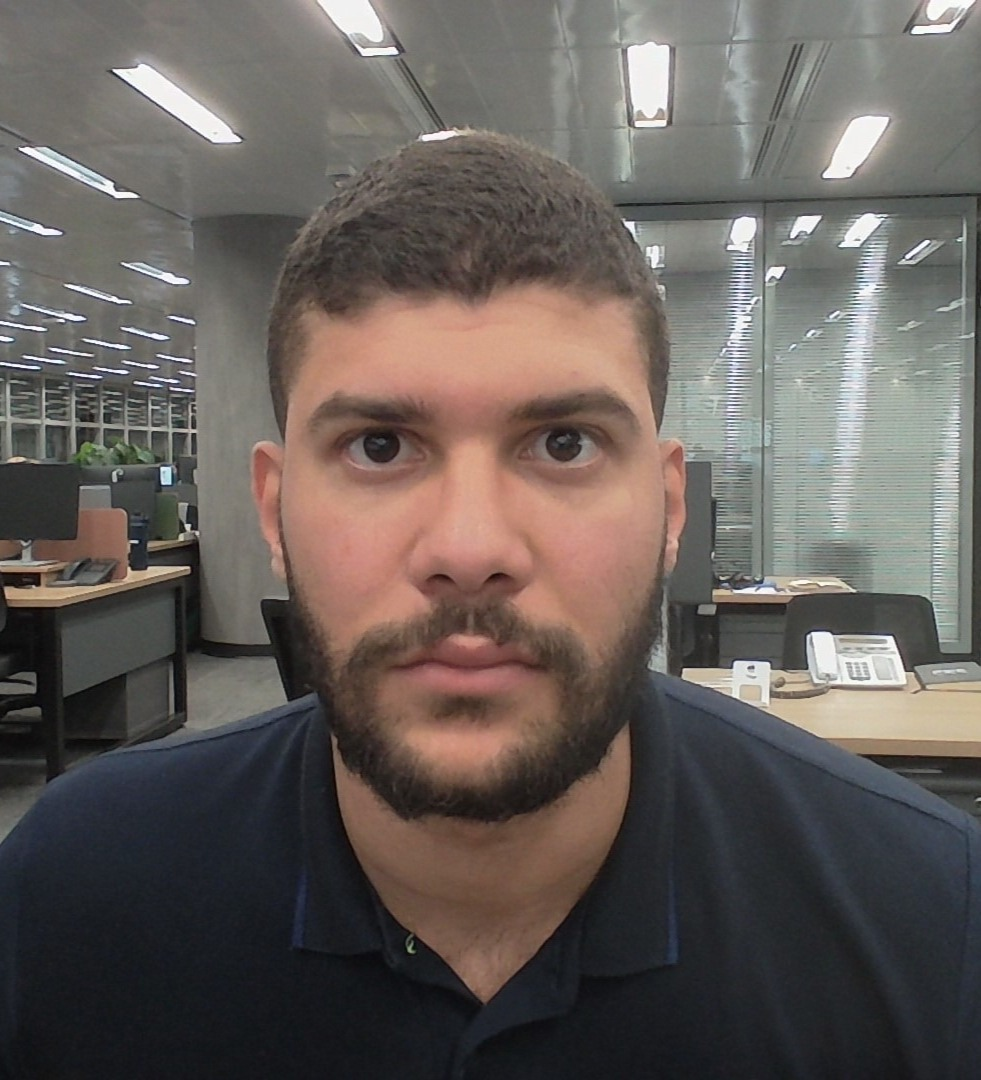

--- Foto 2/2 ---
📂 Selecione uma foto (JPG/PNG) no seu dispositivo...


Saving WIN_20260213_13_01_19_Pro.jpg to WIN_20260213_13_01_19_Pro (1).jpg
✅ Foto salva em: /content/POS-DATASCIENCE-IA/TrabalhoFinal/data/enroll/cliente_008/img2.jpg  (1920×1080 px, 367 KB)
✅ Face detectada (confiança=0.918)


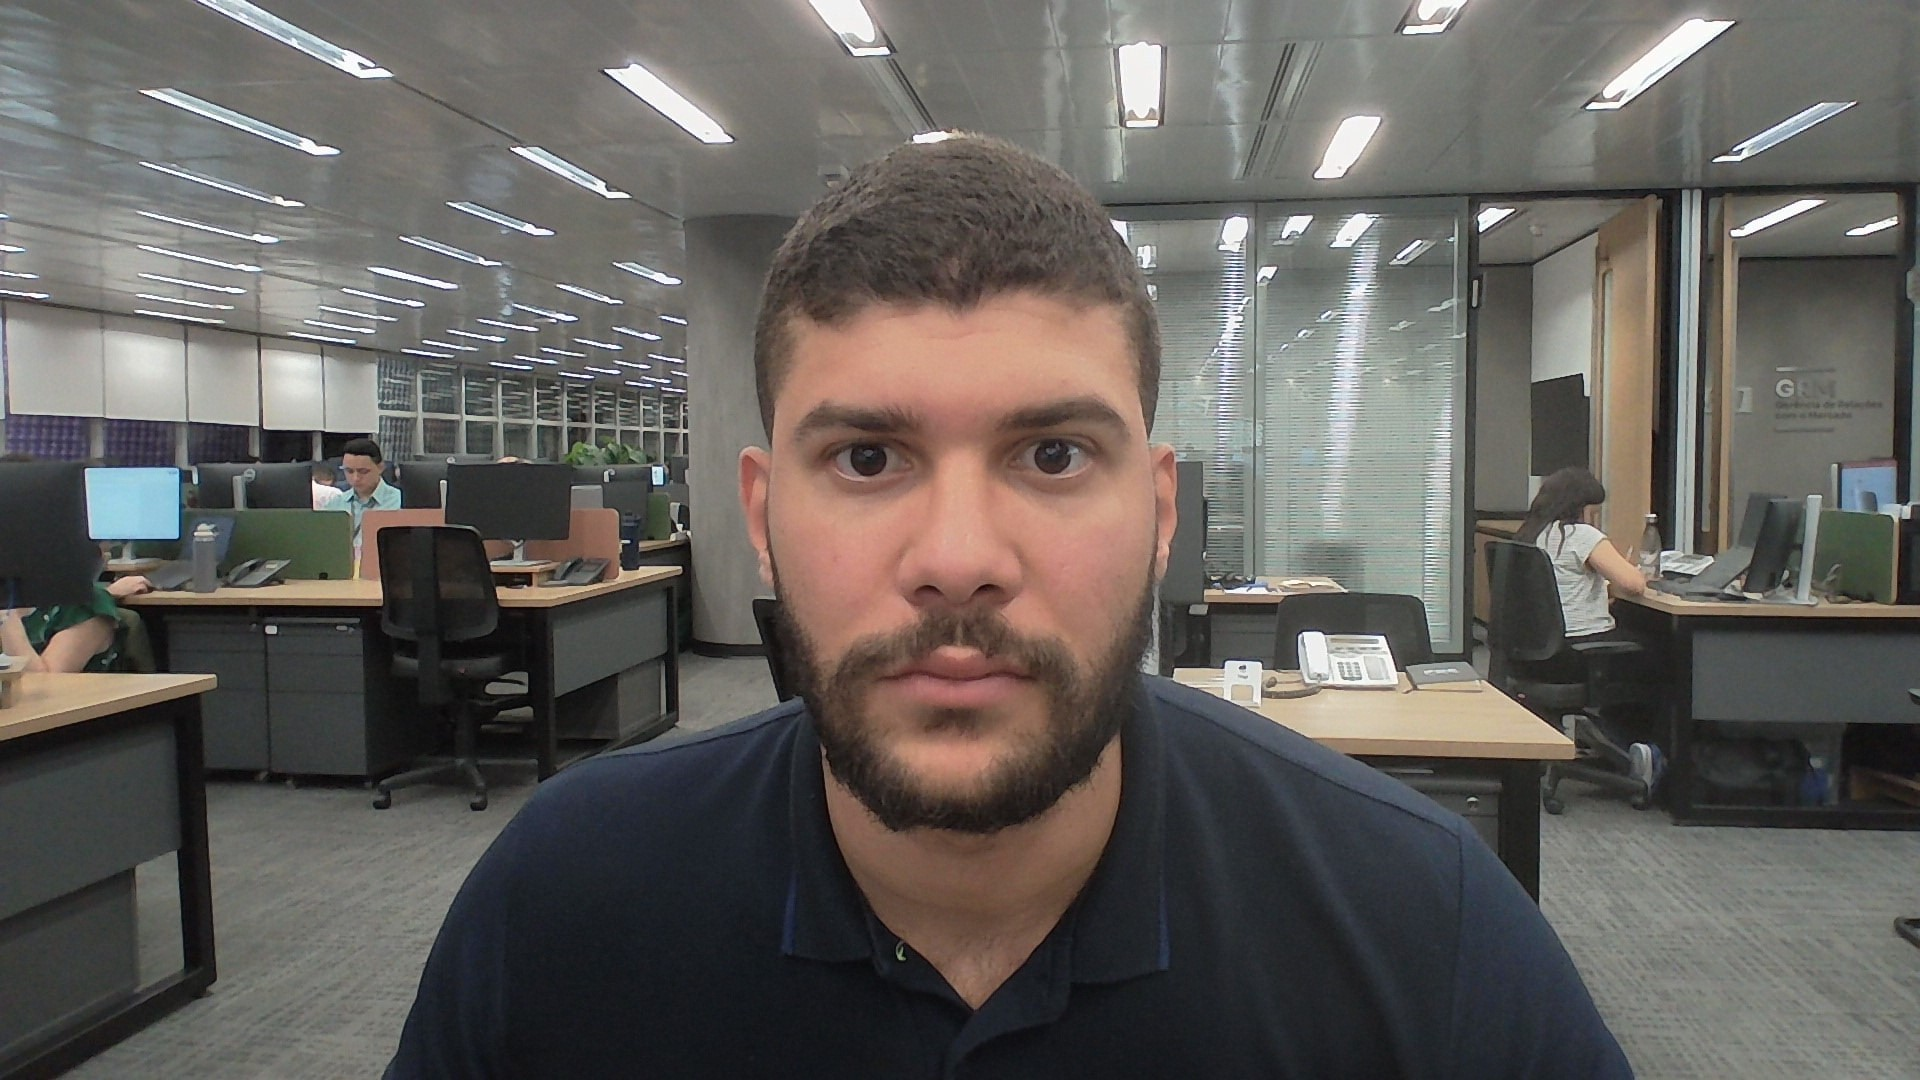


✅ Cadastro de 'cliente_008' concluído! → /content/POS-DATASCIENCE-IA/TrabalhoFinal/data/enroll/cliente_008


In [24]:
# ============================================================
# Cadastro de cliente (Enrollment)
#
# MODO = "webcam"  → captura fotos via câmera do navegador
# MODO = "upload"  → faz upload de fotos salvas no seu dispositivo
#
# Altere CLIENTE_ID, N_FOTOS e MODO antes de executar.
# ============================================================
import IPython.display as display
from IPython.display import Image as IPyImage

# ← Ajuste aqui
CLIENTE_ID = "cliente_008"
N_FOTOS    = 2       # recomendado: 3 a 5
MODO       = "upload"  # "webcam" ou "upload"

enroll_dir_cliente = ENROLL_DIR / CLIENTE_ID
enroll_dir_cliente.mkdir(parents=True, exist_ok=True)

print(f"📋 Cadastrando cliente: {CLIENTE_ID}")
print(f"   Modo: {MODO} | {N_FOTOS} fotos serão capturadas")
if MODO == "webcam":
    print("   Mude levemente a posição/inclinação entre cada foto.\n")
else:
    print("   Faça upload de fotos diferentes do mesmo cliente (frente, leve ângulo, etc.).\n")

for i in range(1, N_FOTOS + 1):
    print(f"--- Foto {i}/{N_FOTOS} ---")
    path = str(enroll_dir_cliente / f"img{i}.jpg")

    if MODO == "webcam":
        take_photo(path)
    else:
        upload_photo(path)

    img   = cv2.imread(path)
    faces = detect_faces(img)
    if len(faces) == 0:
        print(f"⚠️  Nenhuma face detectada na foto {i}. Tente com melhor iluminação.")
    else:
        print(f"✅ Face detectada (confiança={float(faces[0][14]):.3f})")

    display.display(IPyImage(path, width=300))

print(f"\n✅ Cadastro de '{CLIENTE_ID}' concluído! → {enroll_dir_cliente}")


###<font color=AFC1D9> **5.2 Teste de Identificação**</font>

Com clientes cadastrados na galeria, execute a célula abaixo para verificar se um novo rosto é reconhecido.


Clientes cadastrados: 6 -> ['cliente_001', 'cliente_002', 'cliente_003', 'cliente_005', 'cliente_007', 'cliente_009']
Resultado identificação: {'status': 'MATCH', 'best_id': 'cliente_002', 'score': 1.0000000356587293}


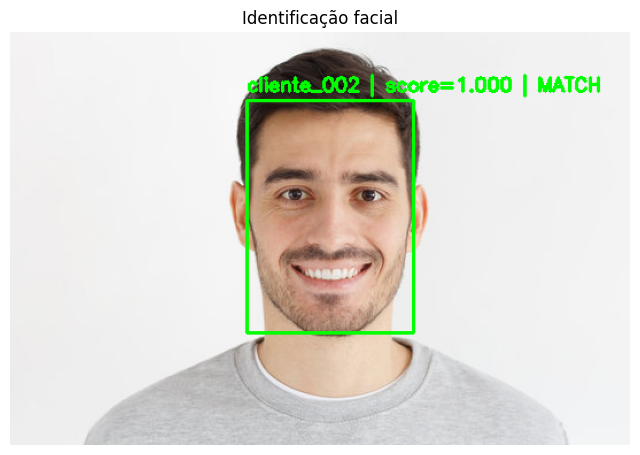

In [ ]:
# Construção da galeria e teste de identificação
gallery = build_gallery(ENROLL_DIR)
print(f"Clientes cadastrados: {len(gallery)} -> {list(gallery.keys())[:10]}")

probe_path = TEST_DIR / "prob.jpg"
if probe_path.exists() and gallery:
    probe = read_image(str(probe_path))
    result = identify_person(probe, gallery, threshold=0.35)
    print("Resultado identificação:", {k: v for k, v in result.items() if k != "face"})

    vis = probe.copy()
    if result["face"] is not None:
        x, y, w, h = map(int, result["face"][:4])
        color = (0, 255, 0) if result["status"] == "MATCH" else (0, 0, 255)
        text = f"{result['best_id']} | score={result['score']:.3f} | {result['status']}"
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
        cv2.putText(vis, text, (x, max(20, y-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Identificação facial")
    plt.show()
else:
    print(f"Garanta dados em {ENROLL_DIR} e uma imagem de teste em {probe_path}")

### Interpretando o score de identificação (similaridade de cosseno)

| Score | Interpretação |
|---|---|
| `≥ 0.593` | **Mesma pessoa** — threshold recomendado pelo OpenCV Zoo |
| `0.35 – 0.59` | Zona de incerteza — depende da qualidade do cadastro |
| `< 0.35` | **Pessoas diferentes** |
| `≈ 1.0` | Mesma imagem comparada consigo mesma (esperado em auto-teste) |

> O notebook usa `threshold=0.35` (conservador) para reduzir falsos bloqueios durante testes. Em produção, ajustaríamos para `0.593` ou calibraríamos com a curva FAR/FRR da **Seção 9**.

> **Score = 1.0** no output anterior ocorre quando a foto de teste é a mesma usada no cadastro — comportamento esperado e correto.


## <font color=#355C7D>**6. Detecção de Vivacidade — Liveness com EAR**</font>

Para evitar fraudes com fotos estáticas, detectamos **piscadas** usando o **Eye Aspect Ratio (EAR)**:

$$EAR = \frac{||p_2 - p_6|| + ||p_3 - p_5||}{2 \cdot ||p_1 - p_4||}$$

Onde p1–p6 são os landmarks dos olhos fornecidos pelo **MediaPipe FaceLandmarker** (478 pontos):

```
        p2 ─── p3
       /           \
  p1 ──               ── p4     ← eixo horizontal (largura do olho)
       \           /
        p6 ─── p5
```

| Estado | EAR típico | O que acontece |
|---|---|---|
| Olho aberto | ~0.30 | Distâncias verticais (p2-p6, p3-p5) são grandes |
| Olho fechado | ~0.15 | Distâncias verticais colidem com zero |
| **Piscada** | cai e sobe | EAR cruza o threshold para baixo e volta |
| **Foto estática** | constante | EAR nunca varia → fraude detectada |

### Por que EAR detecta fraude com foto estática?
Uma foto impressa ou exibida em tela tem EAR **constante** ao longo de todos os frames — nunca ocorrerá a variação característica de uma piscada real. O algoritmo exige que essa variação aconteça para declarar o usuário como *vivo*.

> ⚠️ **Instale o MediaPipe apenas se necessário** — o Colab pode precisar reiniciar o kernel após a instalação.


In [ ]:
!pip install mediapipe==0.10.31

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# moviepy e cv2_imshow não são usados no liveness e causam SyntaxWarnings
# no Python 3.12+, por isso foram removidos desta seção.

BaseOptions           = mp.tasks.BaseOptions
FaceLandmarker        = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode     = mp.tasks.vision.RunningMode

print("✅ MediaPipe Tasks API importado com sucesso.")


✅ MediaPipe Tasks API importado com sucesso.


In [ ]:
# ============================================================
# 3) Detecção de vivacidade (Liveness) — FaceLandmarker Tasks API
#
# Abordagem: EAR (Eye Aspect Ratio) para detectar piscadas.
# Usa o modelo face_landmarker.task (padrão do professor — aula 4),
# com a Tasks API do MediaPipe no modo VIDEO (detect_for_video),
# que mantém tracking temporal entre frames — igual ao professor
# usa para processamento de sequências de vídeo.
#
# EAR < threshold  → olho fechado
# EAR >= threshold → olho aberto
# Piscada = transição fechado → aberto
# ============================================================

# Índices dos pontos dos olhos no modelo FaceLandmarker (478 landmarks)
# Mapeamento padrão MediaPipe para EAR: [P1, P2, P3, P4, P5, P6]
#   P1=canto interno, P4=canto externo, P2/P3=superior, P5/P6=inferior
LEFT_EYE_IDX  = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_IDX = [362, 385, 387, 263, 373, 380]


def euclid(a, b):
    """Distância euclidiana — equivalente a scipy.spatial.distance.euclidean."""
    return dist.euclidean(a, b)


def eye_aspect_ratio(pts):
    """
    EAR (Eye Aspect Ratio) — Soukupová & Čech (2016).

    EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)

    Quanto menor o valor, mais fechado está o olho.
    """
    p1, p2, p3, p4, p5, p6 = pts
    a = euclid(p2, p6)
    b = euclid(p3, p5)
    c = euclid(p1, p4)
    return (a + b) / (2.0 * c + 1e-8)


def liveness_blink_from_frames(
    frames_bgr: list,
    ear_threshold: float = 0.20,
    min_blinks: int = 1,
    fps: float = 30.0
) -> dict:
    """
    Detecta piscadas em uma sequência de frames BGR usando o
    FaceLandmarker da MediaPipe Tasks API no modo VIDEO.

   Utiliza VisionRunningMode.VIDEO
    com detect_for_video() e timestamps monotônicos crescentes, garantindo
    tracking temporal correto entre os frames.

    Parâmetros:
        frames_bgr    : lista de frames numpy BGR
        ear_threshold : EAR abaixo desse valor = olho fechado
        min_blinks    : mínimo de piscadas para considerar vivo
        fps           : frames por segundo estimado (para calcular timestamps)

    Retorna dict: is_live, blink_count, ear_mean, ear_min
    """
    if not frames_bgr:
        return {"is_live": False, "blink_count": 0, "ear_mean": 0.0, "ear_min": 0.0}

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(LANDMARKER_PATH)),
        running_mode=VisionRunningMode.VIDEO,   # modo vídeo: detect_for_video()
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
    )

    blink_count, was_closed = 0, False
    ear_values = []
    frame_interval_ms = int(1000.0 / fps)   # intervalo em ms entre frames

    with FaceLandmarker.create_from_options(options) as landmarker:
        for frame_idx, frame in enumerate(frames_bgr):
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

            # detect_for_video exige timestamp em ms (deve ser monotônico crescente)
            timestamp_ms = frame_idx * frame_interval_ms
            result       = landmarker.detect_for_video(mp_img, timestamp_ms)

            if not result.face_landmarks:
                continue

            h, w  = frame.shape[:2]
            lm    = result.face_landmarks[0]

            left_pts  = [(lm[i].x * w, lm[i].y * h) for i in LEFT_EYE_IDX]
            right_pts = [(lm[i].x * w, lm[i].y * h) for i in RIGHT_EYE_IDX]

            ear = (eye_aspect_ratio(left_pts) + eye_aspect_ratio(right_pts)) / 2.0
            ear_values.append(float(ear))

            if ear < ear_threshold and not was_closed:
                was_closed = True
            elif ear >= ear_threshold and was_closed:
                blink_count += 1
                was_closed   = False

    is_live = blink_count >= min_blinks
    return {
        "is_live":     bool(is_live),
        "blink_count": int(blink_count),
        "ear_mean":    float(np.mean(ear_values)) if ear_values else 0.0,
        "ear_min":     float(np.min(ear_values))  if ear_values else 0.0,
    }


# ── Teste rápido de sanidade com lista vazia ────────────────
_test = liveness_blink_from_frames([])
print("FaceLandmarker Tasks API carregado com sucesso.")
print(f"Teste (frames vazios): {_test}")


FaceLandmarker Tasks API carregado com sucesso.
Teste (frames vazios): {'is_live': False, 'blink_count': 0, 'ear_mean': 0.0, 'ear_min': 0.0}


###<font color=AFC1D9> **6.1 Visualização do EAR ao longo dos frames**</font>

Execute a célula abaixo **após** capturar os frames de liveness (Seção 7 ou teste manual). O gráfico mostra a curva EAR frame a frame, o threshold e marca visualmente cada piscada detectada — útil para depurar problemas de sensibilidade ou entender o comportamento do algoritmo.


In [ ]:
def plot_ear_timeline(frames_bgr: list, ear_threshold: float = 0.20,
                      title: str = "EAR ao longo dos frames") -> dict:
    """
    Processa uma lista de frames BGR, calcula o EAR em cada um e plota
    a curva temporal com threshold e marcações de piscadas.

    Parâmetros
    ----------
    frames_bgr    : lista de arrays NumPy (BGR) capturados via Opção A ou B
    ear_threshold : valor abaixo do qual o olho é considerado fechado (padrão: 0.20)
    title         : título do gráfico

    Como usar
    ---------
    Após capturar frames com capture_frames() ou upload_video_and_extract_frames(),
    chame: plot_ear_timeline(frames_liveness)
    """
    if not frames_bgr:
        print("⚠️  Nenhum frame fornecido.")
        return {}

    from scipy.spatial import distance as dist

    # Configura as opções do FaceLandmarker para detecção no modo de vídeo
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(LANDMARKER_PATH)),
        running_mode=VisionRunningMode.VIDEO, # Modo vídeo para tracking temporal
        num_faces=1, # Detectar apenas uma face
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )

    # Índices dos pontos dos olhos para cálculo do EAR
    LEFT_EYE_IDX  = [33, 160, 158, 133, 153, 144]
    RIGHT_EYE_IDX = [362, 385, 387, 263, 373, 380]

    def ear(pts):
        """Calcula o Eye Aspect Ratio (EAR) para um conjunto de 6 pontos de um olho."""
        p1, p2, p3, p4, p5, p6 = pts
        return (dist.euclidean(p2, p6) + dist.euclidean(p3, p5)) / (
            2.0 * dist.euclidean(p1, p4) + 1e-8
        )

    ear_values, blink_frames = [], []
    was_closed = False
    frame_interval_ms = 33  # Aproximadamente 30 fps (1000 ms / 30 fps)

    # Inicializa o FaceLandmarker e processa cada frame
    with FaceLandmarker.create_from_options(options) as lm_model:
        for idx, frame in enumerate(frames_bgr):
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            # Detecta landmarks para o frame no modo de vídeo com timestamp
            result = lm_model.detect_for_video(mp_img, idx * frame_interval_ms)
            if not result.face_landmarks:
                ear_values.append(None) # Adiciona None se nenhuma face for detectada
                continue
            h, w  = frame.shape[:2]
            lm    = result.face_landmarks[0] # Pega os landmarks da primeira face

            # Extrai os pontos dos olhos e calcula o EAR médio
            l_pts = [(lm[i].x * w, lm[i].y * h) for i in LEFT_EYE_IDX]
            r_pts = [(lm[i].x * w, lm[i].y * h) for i in RIGHT_EYE_IDX]
            e = (ear(l_pts) + ear(r_pts)) / 2.0
            ear_values.append(float(e))

            # Lógica para detecção de piscadas
            if e < ear_threshold and not was_closed: # Olho fechou
                was_closed = True
            elif e >= ear_threshold and was_closed: # Olho abriu após estar fechado
                blink_frames.append(idx) # Registra o frame onde a piscada ocorreu
                was_closed = False

    # Filtra os valores EAR válidos (onde faces foram detectadas)
    valid = [(i, v) for i, v in enumerate(ear_values) if v is not None]
    if not valid:
        print("⚠️  Nenhum landmark facial encontrado nos frames. Verifique iluminação e posição.")
        return {}

    x_vals = [v[0] for v in valid] # Índices dos frames
    y_vals = [v[1] for v in valid] # Valores EAR correspondentes

    # Cria e configura o gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(x_vals, y_vals, color="#2196F3", linewidth=1.8, label="EAR médio (ambos os olhos)")

    # Desenha a linha do threshold EAR
    plt.axhline(ear_threshold, color="#F44336", linestyle="--", linewidth=1.5,
                label=f"Threshold EAR = {ear_threshold:.2f}")

    # Marca os frames onde piscadas foram detectadas
    for bf in blink_frames:
        plt.axvline(bf, color="#4CAF50", linestyle=":", alpha=0.8)
    if blink_frames:
        plt.axvline(blink_frames[0], color="#4CAF50", linestyle=":", # Adiciona label apenas uma vez
                    alpha=0.8, label=f"Piscada detectada ({len(blink_frames)}x)")

    # Preenche a área abaixo do threshold para indicar "olho fechado"
    plt.fill_between(
        x_vals, y_vals, ear_threshold,
        where=[y < ear_threshold for y in y_vals],
        color="#F44336", alpha=0.15, label="Região olho fechado",
    )

    # Adiciona rótulos e título
    plt.xlabel("Frame")
    plt.ylabel("EAR")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Imprime estatísticas da análise
    print(f"  Frames válidos : {len(valid)}/{len(frames_bgr)}")
    print(f"  EAR médio      : {sum(y_vals)/len(y_vals):.4f}")
    print(f"  EAR mínimo     : {min(y_vals):.4f}")
    print(f"  Piscadas       : {len(blink_frames)}")
    return {"ear_values": ear_values, "blink_frames": blink_frames}


# Exemplo de uso (descomente e substitua frames_liveness pelos seus frames reais):
# plot_ear_timeline(frames_liveness, ear_threshold=0.20)
print("✅ plot_ear_timeline() pronta. Chame após capturar frames de liveness.")

✅ plot_ear_timeline() pronta. Chame após capturar frames de liveness.


## <font color=#355C7D>**7. Pipeline Completo de Autenticação**</font>

Combina identificação facial (SFace) + vivacidade (EAR) em uma única decisão: **APROVADO** ou **EM_REVISAO**.

Casos de **EM_REVISAO** e o motivo específico:
- `NO_FACE` — nenhum rosto detectado na imagem.
- `ID_FAIL` — rosto detectado, mas não reconhecido na galeria (score < threshold).
- `LIVENESS_FAIL` — rosto reconhecido, mas vivacidade reprovada (sem piscada detectada).
- `ID_LIVENESS_FAIL` — falha em ambos os critérios.

Evidências de falha (imagem + JSON) são salvas automaticamente em `evidencias/` para auditoria e alimentam o processo de retreino.


Clientes na galeria: ['cliente_001', 'cliente_002', 'cliente_003', 'cliente_005', 'cliente_007', 'cliente_008', 'cliente_009']

📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO
   Olhe diretamente para a câmera e clique em 'Capturar Foto'.


<IPython.core.display.Javascript object>

📷 Foto salva em: /content/POS-DATASCIENCE-IA/TrabalhoFinal/data/test/probe.jpg

👁  PASSO 2/2 — Captura para LIVENESS (detecção de piscada via EAR)
   Aguarde a contagem regressiva e PISCE os olhos durante a gravação.


<IPython.core.display.Javascript object>

✅ 25 frames capturados para liveness.

{
  "timestamp": "2026-05-27T00:02:28.138446",
  "decision": "APROVADO",
  "failure_code": null,
  "reason": "Identidade confirmada e liveness aprovado.",
  "identificacao": {
    "status": "MATCH",
    "best_id": "cliente_008",
    "score": 0.7192135812201741,
    "threshold": 0.35
  },
  "liveness": {
    "is_live": true,
    "blink_count": 1,
    "ear_mean": 0.28538502858734593,
    "ear_min": 0.151365450926905
  }
}


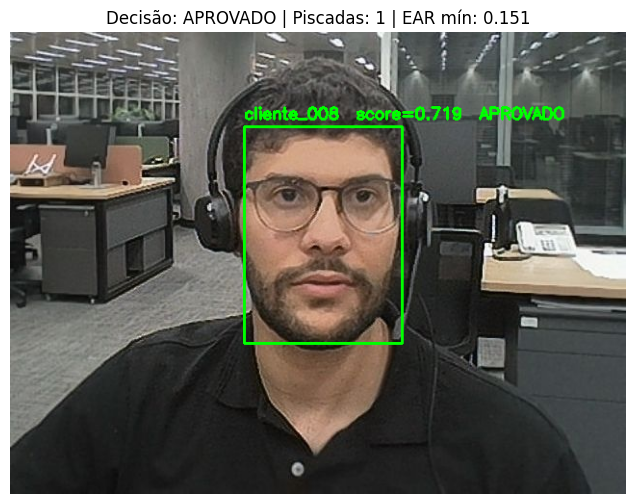


📁 Registro salvo (auditoria):
   Imagem   : /content/POS-DATASCIENCE-IA/TrabalhoFinal/evidencias/aprovado_20260527_000228.jpg
   Metadados: /content/POS-DATASCIENCE-IA/TrabalhoFinal/evidencias/aprovado_20260527_000228.json


In [25]:
# ============================================================
# Funções de decisão e salvamento de evidências
# ============================================================

def save_evidence(probe_img_bgr, decision_payload: dict, prefix: str = "tentativa"):
    """
    Salva a imagem da tentativa e os metadados da decisão como evidência.

    Parâmetros
    ----------
    probe_img_bgr    : Imagem BGR da tentativa de autenticação.
    decision_payload : Dicionário contendo todos os detalhes da decisão.
    prefix           : Prefixo para o nome dos arquivos de evidência (ex: 'em_revisao', 'aprovado').

    Retorna
    -------
    tuple: Caminhos completos para a imagem e o arquivo JSON salvos.
    """
    # Gera um timestamp para garantir nomes de arquivo únicos
    ts        = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Define os caminhos completos para a imagem e os metadados JSON
    img_path  = EVIDENCE_DIR / f"{prefix}_{ts}.jpg"
    meta_path = EVIDENCE_DIR / f"{prefix}_{ts}.json"
    # Salva a imagem
    cv2.imwrite(str(img_path), probe_img_bgr)
    # Salva os metadados como JSON
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(decision_payload, f, ensure_ascii=False, indent=2)
    return str(img_path), str(meta_path)


def auth_decision(probe_img_bgr, gallery: dict, liveness_result: dict,
                  id_threshold: float = 0.35) -> dict:
    """
    Pipeline completo de autenticação que combina identificação facial e detecção de vivacidade.

    Parâmetros
    ----------
    probe_img_bgr   : Imagem BGR do usuário tentando se autenticar.
    gallery         : Galeria de embeddings faciais de clientes cadastrados.
    liveness_result : Resultado da detecção de vivacidade (dicionário com 'is_live', 'blink_count', etc.).
    id_threshold    : Limiar de similaridade de cosseno para identificação facial.

    Retorna
    -------
    dict: Payload detalhado da decisão de autenticação (APROVADO ou EM_REVISAO).
    """
    # Realiza a identificação facial usando a imagem da sonda e a galeria
    id_result  = identify_person(probe_img_bgr, gallery, threshold=id_threshold)
    # Verifica se a identificação foi bem-sucedida ('MATCH')
    id_ok      = id_result["status"] == "MATCH"
    # Verifica se a detecção de vivacidade foi bem-sucedida ('is_live' = True)
    live_ok    = liveness_result.get("is_live", False)
    # A autenticação é aprovada apenas se AMBOS os critérios forem atendidos
    approved   = id_ok and live_ok

    # ── Motivo específico de reprovação ─────────────────────
    # Determina o motivo da falha para casos de 'EM_REVISAO'
    if approved:
        reason = "Identidade confirmada e liveness aprovado."
        failure_code = None
    elif id_result["status"] == "NO_FACE":
        reason = "Nenhum rosto detectado na imagem."
        failure_code = "NO_FACE"
    elif not id_ok and not live_ok:
        reason = "Falha na identificação facial E na detecção de vivacidade."
        failure_code = "ID_LIVENESS_FAIL"
    elif not id_ok:
        reason = "Rosto detectado, mas não reconhecido na galeria (score abaixo do threshold)."
        failure_code = "ID_FAIL"
    else:
        reason = "Identidade confirmada, mas vivacidade reprovada (piscada não detectada)."
        failure_code = "LIVENESS_FAIL"

    # Constrói o payload da decisão com todos os detalhes
    payload = {
        "timestamp":    datetime.now().isoformat(),
        "decision":     "APROVADO" if approved else "EM_REVISAO",
        "failure_code": failure_code,
        "reason":       reason,
        "identificacao": {
            "status":    id_result["status"],
            "best_id":   id_result["best_id"],
            "score":     id_result["score"],
            "threshold": id_threshold,
        },
        "liveness": liveness_result,
    }

    # ── Esteira dedicada: salvar evidência sempre que EM_REVISAO ─────────
    # Se a decisão for 'EM_REVISAO', salva as evidências para análise posterior
    if not approved:
        img_evd, json_evd = save_evidence(probe_img_bgr, payload, prefix="em_revisao")
        payload["evidence"] = {"image": img_evd, "metadata": json_evd}
        print(f"\n⚠️  ENCAMINHADO À ESTEIRA DE FRAUDES")
        print(f"   Motivo : {reason}")
        print(f"   Imagem : {img_evd}")
        print(f"   JSON   : {json_evd}")

    return payload


# ============================================================
# Fluxo completo de autenticação
# Este bloco de código orquestra todo o processo de autenticação.
# ============================================================

# Define os modos de captura para identificação e vivacidade (webcam ou upload)
MODO_ID       = "webcam"   # "webcam" ou "upload" (para a foto de identificação)
MODO_LIVENESS = "webcam"   # "webcam" ou "upload" (para os frames de liveness)

# Constrói a galeria de clientes cadastrados a partir do diretório ENROLL_DIR
gallery = build_gallery(ENROLL_DIR)
print(f"Clientes na galeria: {list(gallery.keys())}")

# Verifica se a galeria está vazia e alerta o usuário se for o caso
if not gallery:
    print("\n⚠️  Galeria vazia! Execute a célula de cadastro (seção 5.1) antes de autenticar.")
else:
    # ── PASSO 1: Captura foto de identificação ──────────────────────────
    print("\n📷 PASSO 1/2 — Captura para IDENTIFICAÇÃO")
    # Define um caminho temporário para salvar a imagem da sonda
    probe_path_tmp = str(TEST_DIR / "probe.jpg")

    # Captura a foto de identificação dependendo do MODO_ID selecionado
    if MODO_ID == "webcam":
        print("   Olhe diretamente para a câmera e clique em 'Capturar Foto'.")
        take_photo(probe_path_tmp) # Chama a função de captura via webcam
    else:
        print("   Faça upload de uma foto sua para identificação.")
        upload_photo(probe_path_tmp) # Chama a função de upload de foto

    # Lê a imagem da sonda capturada/uploadada
    probe = read_image(probe_path_tmp)

    # ── PASSO 2: Captura de frames para liveness ────────────────────────
    print("\n👁  PASSO 2/2 — Captura para LIVENESS (detecção de piscada via EAR)")
    frames_liveness = []
    # Captura os frames para detecção de vivacidade dependendo do MODO_LIVENESS
    if MODO_LIVENESS == "webcam":
        print("   Aguarde a contagem regressiva e PISCE os olhos durante a gravação.")
        frames_liveness = capture_frames(n_frames=25, interval_ms=150) # Captura frames via webcam
    else:
        print("   Envie um vídeo curto (2–4 s) onde você pisque pelo menos uma vez.")
        frames_liveness = upload_video_and_extract_frames(max_frames=40) # Upload e extração de frames de vídeo

    # Se frames de liveness não foram capturados, alerta o usuário
    if not frames_liveness:
        print("⚠️  Nenhum frame capturado. Tente novamente.")
    else:
        # ── PASSO 3: Pipeline de decisão ────────────────────────────────
        # Realiza a detecção de vivacidade nos frames capturados
        live_result      = liveness_blink_from_frames(frames_liveness, ear_threshold=0.20, min_blinks=1)
        # Chama a função principal de decisão de autenticação
        decision_payload = auth_decision(probe, gallery, live_result, id_threshold=0.35)

        # ── Exibe resultado completo ──────────────────────────────────────
        print("\n" + "=" * 60)
        # Imprime o payload da decisão em formato JSON legível
        print(json.dumps(decision_payload, ensure_ascii=False, indent=2))
        print("=" * 60)

        # ── Visualização com bounding box e veredito ─────────────────────
        vis      = probe.copy()
        id_res   = decision_payload["identificacao"]
        # Re-detecta a face na imagem da sonda para desenhar a bounding box
        face_res = identify_person(probe, gallery)
        if face_res["face"] is not None:
            # Extrai coordenadas da bounding box
            x, y, w, h = map(int, face_res["face"][:4])
            # Define a cor da bounding box com base na decisão (verde para APROVADO, vermelho para EM_REVISAO)
            color = (0, 255, 0) if decision_payload["decision"] == "APROVADO" else (0, 0, 255)
            # Cria o rótulo com ID, score e decisão
            label = (
                f"{id_res['best_id']}  score={id_res['score']:.3f}  "
                f"{decision_payload['decision']}"
            )
            # Desenha o retângulo e o texto na imagem
            cv2.rectangle(vis, (x, y), (x + w, y + h), color, 2)
            cv2.putText(vis, label, (x, max(20, y - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        # Exibe a imagem visualizada com a decisão
        plt.figure(figsize=(8, 6))
        plt.title(
            f"Decisão: {decision_payload['decision']} | "
            f"Piscadas: {live_result['blink_count']} | "
            f"EAR mín: {live_result['ear_min']:.3f}"
        )
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        # ── Salva evidências para casos APROVADO (auditoria completa) ────
        # Se a autenticação foi 'APROVADO', salva as evidências para auditoria
        if decision_payload["decision"] == "APROVADO":
            img_evd, json_evd = save_evidence(probe, decision_payload, prefix="aprovado")
            print(f"\n📁 Registro salvo (auditoria):")
            print(f"   Imagem   : {img_evd}")
            print(f"   Metadados: {json_evd}")

## <font color=#355C7D>**8. Esteira Dedicada de Fraudes**</font>

Quando a decisão for **EM_REVISAO**, o cliente **não é bloqueado automaticamente** — ele é direcionado a um canal de atendimento alternativo (ex.: agente humano, verificação adicional via SMS/email).

As evidências salvas automaticamente em `evidencias/` contêm:
- **Imagem JPG** do rosto capturado na tentativa.
- **JSON** com timestamp, motivo da falha (`failure_code`), scores de identificação e métricas de EAR/piscadas.

### Fluxo na área de IA/Fraudes
```
evidencias/em_revisao_YYYYMMDD_HHMMSS.jpg  ─┐
evidencias/em_revisao_YYYYMMDD_HHMMSS.json ─┤→ Revisão humana → rótulo (fraude / falso negativo)
                                             └→ Dataset de retreino → ajuste de thresholds
```
| `failure_code` | Significado | Ação sugerida |
|---|---|---|
| `NO_FACE` | Câmera coberta ou iluminação ruim | Solicitar nova tentativa |
| `ID_FAIL` | Rosto não reconhecido | Encaminhar ao atendimento humano |
| `LIVENESS_FAIL` | Sem piscada — possível foto estática | Suspeita de fraude; acionar time de segurança |
| `ID_LIVENESS_FAIL` | Falha dupla | Alta prioridade para revisão |


## <font color=#355C7D>**9. Ajuste de Limiares e Governança**</font>

> Use uma base de validação separada e ajuste os limiares para equilibrar segurança e fricção ao cliente.

- `threshold_identificacao`: aumente para reduzir falso aceite (fraude), diminua para reduzir falso bloqueio.
- `ear_threshold` e `min_blinks`: calibrar por câmera/dispositivo e perfil de usuário.
- Em serviços críticos (ex.: crédito pessoal), exigir **3 fatores**: senha + face + liveness ativo.

### Métricas de avaliação do modelo
| Métrica | Fórmula | Significado |
|---|---|---|
| **FAR** (False Accept Rate) | FP / (FP + TN) | Taxa de fraudes aceitas erroneamente |
| **FRR** (False Reject Rate) | FN / (FN + TP) | Taxa de clientes legítimos bloqueados |
| **EER** (Equal Error Rate) | ponto onde FAR = FRR | Threshold ótimo de operação |

O threshold deve ser definido **por produto** de acordo com o risco:
- Crédito pessoal → threshold mais alto (menor FAR, aceita mais bloqueios).
- Consulta de saldo → threshold mais baixo (menor FRR, menos fricção).


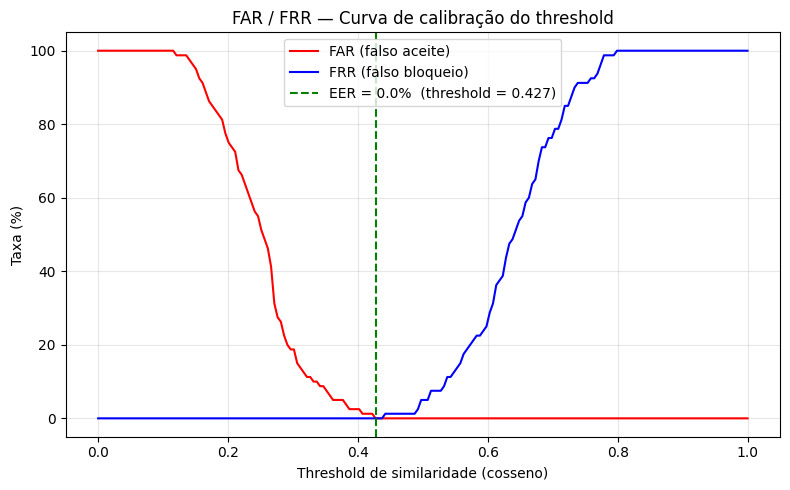

EER threshold: 0.427  |  EER: 0.00%
→ Use esse threshold como ponto de partida para produção.
→ Para crédito pessoal, aumente ligeiramente (reduz FAR).


In [ ]:
# ============================================================
# Cálculo demonstrativo de FAR, FRR e EER
# Use com sua base de validação rotulada.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def compute_far_frr(scores: list, labels: list, thresholds: np.ndarray):
    """
    Calcula o False Accept Rate (FAR) e o False Reject Rate (FRR)
    para uma série de thresholds, dados os scores de similaridade e os rótulos verdadeiros.

    Parâmetros
    ----------
    scores  : lista de scores de similaridade (cosseno) de cada tentativa.
              Um score alto indica maior similaridade.
    labels  : lista de rótulos verdadeiros (1 = cliente legítimo, 0 = impostor).
    thresholds: array de thresholds a serem avaliados.

    Retorna
    -------
    tuple: Arrays NumPy contendo os valores de FAR e FRR para cada threshold.
    """
    far_list, frr_list = [], []
    for thr in thresholds:
        # Predições: 1 se score >= threshold (aceito), 0 caso contrário (rejeitado)
        predictions = [1 if s >= thr else 0 for s in scores]

        # Contagem de resultados para o cálculo de FAR
        # FP (False Positive): Impostor aceito (predito 1, real 0)
        fp = sum(1 for p, l in zip(predictions, labels) if p == 1 and l == 0)
        # TN (True Negative): Impostor rejeitado (predito 0, real 0)
        tn = sum(1 for p, l in zip(predictions, labels) if p == 0 and l == 0)

        # Contagem de resultados para o cálculo de FRR
        # FN (False Negative): Legítimo bloqueado (predito 0, real 1)
        fn = sum(1 for p, l in zip(predictions, labels) if p == 0 and l == 1)
        # TP (True Positive): Legítimo aceito (predito 1, real 1)
        tp = sum(1 for p, l in zip(predictions, labels) if p == 1 and l == 1)

        # Calcula FAR = FP / (FP + TN) e FRR = FN / (FN + TP)
        # Adiciona 1e-9 para evitar divisão por zero
        far_list.append(fp / (fp + tn + 1e-9))
        frr_list.append(fn / (fn + tp + 1e-9))

    return np.array(far_list), np.array(frr_list)


# ── Dados de exemplo (substitua pelos scores reais da validação) ──────────
np.random.seed(42) # Para reprodutibilidade
# Gera scores simulados para clientes legítimos (distribuição com média alta)
legit_scores   = np.clip(np.random.normal(0.65, 0.08, 80), 0, 1)
# Gera scores simulados para impostores (distribuição com média baixa)
impostor_scores = np.clip(np.random.normal(0.25, 0.07, 80), 0, 1)

# Combina os scores e cria os rótulos correspondentes
scores = list(legit_scores) + list(impostor_scores)
labels = [1] * 80 + [0] * 80 # 1 para legítimos, 0 para impostores

# Define uma gama de thresholds para avaliar
thresholds = np.linspace(0.0, 1.0, 200)
# Calcula FAR e FRR para cada threshold
far, frr   = compute_far_frr(scores, labels, thresholds)

# EER (Equal Error Rate): ponto onde FAR e FRR são aproximadamente iguais
# Encontra o índice do threshold onde a diferença absoluta entre FAR e FRR é mínima
eer_idx = np.argmin(np.abs(far - frr))
# O threshold correspondente ao EER
eer_thr = thresholds[eer_idx]
# O valor do EER (média de FAR e FRR neste ponto)
eer_val = (far[eer_idx] + frr[eer_idx]) / 2

# ── Plotagem da curva FAR/FRR ──────────────────────────────────────
plt.figure(figsize=(8, 5))
# Plota a curva FAR (em porcentagem)
plt.plot(thresholds, far * 100, label="FAR (falso aceite)", color="red")
# Plota a curva FRR (em porcentagem)
plt.plot(thresholds, frr * 100, label="FRR (falso bloqueio)", color="blue")
# Desenha uma linha vertical no threshold do EER
plt.axvline(eer_thr, color="green", linestyle="--",
            label=f"EER = {eer_val*100:.1f}%  (threshold = {eer_thr:.3f})")

# Configurações do gráfico
plt.xlabel("Threshold de similaridade (cosseno)")
plt.ylabel("Taxa (%)")
plt.title("FAR / FRR — Curva de calibração do threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Imprime os resultados do EER
print(f"EER threshold: {eer_thr:.3f}  |  EER: {eer_val*100:.2f}%")
print("→ Use esse threshold como ponto de partida para produção.")
print("→ Para crédito pessoal, aumente ligeiramente (reduz FAR).")

### Interpretação dos resultados

| Valor calculado | Resultado |
|---|---|
| **Threshold EER** | 0.427 (com dados simulados) |
| **EER** | 0.00% (separação perfeita nos dados simulados) |

**Por que EER = 0.00% nos dados simulados?**  
Os scores foram gerados com distribuições normais bem separadas (legítimos: média 0.65, desvio 0.08; impostores: média 0.25, desvio 0.07). O threshold 0.427 cai exatamente no gap entre as duas distribuições — sem sobreposição, resultando em FAR = FRR = 0.

**Na prática com dados reais:**  
Distribuições de legítimos e impostores sempre se sobrepõem. EER típico para sistemas faciais:

| Contexto | EER aceitável | Prioridade |
|---|---|---|
| Crédito pessoal | ≤ 2% | Baixo FAR (menos fraudes aceitas) |
| Consulta de saldo | ≤ 5% | Baixo FRR (menos bloqueios legítimos) |
| Transferência de alto valor | ≤ 1% + fator adicional | Máxima segurança |



## <font color=#355C7D>**10. Próximos passos**</font>

1. Substituir `legit_scores` e `impostor_scores` pelos scores reais da galeria de validação.
2. Executar `compute_far_frr()` com os dados reais para obter o EER e threshold real.
3. Ajustar o threshold por produto (crédito vs. consulta).
4. Registrar todas as tentativas em `evidencias/` e retreinar periodicamente com os dados rotulados.
